<a href="https://colab.research.google.com/github/shobhitgh-rs/Data-Science-Internship-Tasks/blob/main/Data_Science_CustomerSegmentation_%26_RetentionAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

file_path = '/content/online_retail_II.xlsx'
try:
    xls = pd.ExcelFile(file_path)
    print(f"Sheet names: {xls.sheet_names}")

    df = pd.read_excel(file_path, sheet_name=xls.sheet_names[0], nrows=5)
    print(df.head())
    print(df.columns)
except Exception as e:
    print(f"Error: {e}")

Sheet names: ['Year 2009-2010', 'Year 2010-2011']
   Invoice StockCode                          Description  Quantity  \
0   489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1   489434    79323P                   PINK CHERRY LIGHTS        12   
2   489434    79323W                  WHITE CHERRY LIGHTS        12   
3   489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4   489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95        13085  United Kingdom  
1 2009-12-01 07:45:00   6.75        13085  United Kingdom  
2 2009-12-01 07:45:00   6.75        13085  United Kingdom  
3 2009-12-01 07:45:00   2.10        13085  United Kingdom  
4 2009-12-01 07:45:00   1.25        13085  United Kingdom  
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')


## 1. Data Loading and Initial Inspection

First, we'll load the full dataset for the 'Year 2009-2010' sheet, as specified in the project requirements. We'll then perform an initial inspection to understand its structure and data types.

In [2]:
# Load the full dataset from the 'Year 2009-2010' sheet
# This is done to ensure all data points are available for cleaning and analysis.
df_full = pd.read_excel(file_path, sheet_name='Year 2009-2010')

# Display basic information about the dataframe to check data types, non-null values, etc.
# This helps in identifying potential issues like missing data or incorrect data types early on.
print("Initial DataFrame Information:")
df_full.info()

# Display the first few rows of the full dataset
# This gives a quick visual check of the data content after loading.
print("\nFirst 5 rows of the full DataFrame:")
display(df_full.head())

Initial DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB

First 5 rows of the full DataFrame:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Data Cleaning

As per the project requirements, we need to perform several data cleaning steps:

1.  **Handle Missing Customer IDs:** Customer ID is crucial for RFM analysis, so we'll remove rows where it's missing.
2.  **Remove Cancellations:** Invoices starting with 'C' indicate cancelled orders, which should not be included in sales analysis.
3.  **Filter Invalid Quantities/Prices:** Negative or zero quantities/prices are typically data entry errors or returns, and are not relevant for calculating customer value.

In [3]:
# 2.1 Handle Missing Values for Customer ID
# Customer ID is essential for identifying unique customers and performing RFM analysis.
# Rows with missing Customer IDs cannot be attributed to any specific customer, so they are dropped.
df_cleaned = df_full.dropna(subset=['Customer ID'])
print(f"Rows after dropping missing Customer IDs: {df_cleaned.shape[0]}")

# Convert 'Customer ID' to integer type for consistency and easier handling.
# This step ensures that customer IDs are treated as numerical identifiers.
df_cleaned['Customer ID'] = df_cleaned['Customer ID'].astype(int)

# 2.2 Remove Canceled Orders
# Invoices starting with 'C' (e.g., 'C489434') indicate cancelled transactions.
# These transactions do not represent actual sales and can skew our analysis, so they are removed.
df_cleaned = df_cleaned[~df_cleaned['Invoice'].astype(str).str.startswith('C')]
print(f"Rows after removing cancelled orders: {df_cleaned.shape[0]}")

# 2.3 Filter Out Negative or Zero Quantities/Prices
# Quantities and Prices must be positive for valid sales transactions.
# Negative values usually indicate returns (which are already handled by removing 'C' invoices, but good to double-check).
# Zero values would imply no monetary transaction, which isn't useful for sales analysis.
df_cleaned = df_cleaned[(df_cleaned['Quantity'] > 0) & (df_cleaned['Price'] > 0)]
print(f"Rows after filtering out invalid quantities/prices: {df_cleaned.shape[0]}")

# Display the info of the cleaned DataFrame to see the updated state
print("\nCleaned DataFrame Information:")
df_cleaned.info()

# Display the first few rows of the cleaned DataFrame to verify the changes
print("\nFirst 5 rows of the Cleaned DataFrame:")
display(df_cleaned.head())

Rows after dropping missing Customer IDs: 417534


/tmp/ipykernel_36258/3867511043.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Customer ID'] = df_cleaned['Customer ID'].astype(int)


Rows after removing cancelled orders: 407695
Rows after filtering out invalid quantities/prices: 407664

Cleaned DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
Index: 407664 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      407664 non-null  object        
 1   StockCode    407664 non-null  object        
 2   Description  407664 non-null  object        
 3   Quantity     407664 non-null  int64         
 4   InvoiceDate  407664 non-null  datetime64[ns]
 5   Price        407664 non-null  float64       
 6   Customer ID  407664 non-null  int64         
 7   Country      407664 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 28.0+ MB

First 5 rows of the Cleaned DataFrame:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


## 3. Feature Engineering: RFM (Recency, Frequency, Monetary) Analysis

RFM analysis is a marketing technique used to quantitatively rank and group customers based on their purchasing behavior. We will calculate three key metrics for each customer:

1.  **Recency (R):** How recently did the customer make a purchase?
2.  **Frequency (F):** How often do they purchase?
3.  **Monetary (M):** How much money do they spend?

To do this, we'll first calculate the `TotalPrice` for each transaction and then determine a 'snapshot date' to calculate Recency.

In [4]:
# Calculate TotalPrice for each transaction
# This is the product of Quantity and Price, representing the revenue for each item in a transaction.
df_cleaned['TotalPrice'] = df_cleaned['Quantity'] * df_cleaned['Price']

# Determine a snapshot date for Recency calculation
# The snapshot date is typically one day after the last transaction date in the dataset.
# This ensures that 'Recency' is calculated as the number of days since the customer's last purchase relative to the most recent activity.
snapshot_date = df_cleaned['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f"Snapshot date for RFM analysis: {snapshot_date}")

Snapshot date for RFM analysis: 2010-12-10 20:01:00


In [5]:
# Group by Customer ID to calculate RFM metrics
rfm_df = df_cleaned.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days), # Days since last purchase
    Frequency=('Invoice', lambda num: num.nunique()),                       # Number of unique invoices (transactions)
    Monetary=('TotalPrice', 'sum')                                         # Total spend by the customer
).reset_index()

# Display the first few rows of the RFM DataFrame
# This shows the calculated Recency, Frequency, and Monetary values for each customer.
print("\nRFM DataFrame head:")
display(rfm_df.head())

# Display descriptive statistics of the RFM DataFrame
# This helps in understanding the distribution of RFM values and identifying potential outliers.
print("\nRFM DataFrame descriptive statistics:")
display(rfm_df.describe())


RFM DataFrame head:


,Customer ID,Recency,Frequency,Monetary
0,12346,165,11,372.86
1,12347,3,2,1323.32
2,12348,74,1,222.16
3,12349,43,3,2671.14
4,12351,11,1,300.93



RFM DataFrame descriptive statistics:


,Customer ID,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,91.171846,4.455705,2048.238236
std,1701.200176,96.860633,8.170213,8914.481280
min,12346.000000,1.000000,1.000000,2.950000
25%,13882.500000,18.000000,1.000000,307.987500
50%,15350.500000,53.000000,2.000000,706.020000
75%,16834.250000,136.000000,5.000000,1723.142500
max,18287.000000,374.000000,205.000000,349164.350000


## 4. RFM Data Preparation for Clustering: Transformation and Scaling

Before applying K-Means clustering, it's good practice to transform and scale the RFM values. This is important for several reasons:

*   **Skewness:** RFM distributions are often highly skewed. Log transformation can help normalize these distributions, making them more symmetrical.
*   **Scale:** The RFM metrics have different scales (e.g., Monetary values can be much larger than Frequency). Scaling brings them to a comparable range, preventing one feature from dominating the distance calculations in clustering.


RFM Log-transformed DataFrame head:


,Recency,Frequency,Monetary
0,5.111988,2.484907,5.923881
1,1.386294,1.098612,7.188654
2,4.317488,0.693147,5.407889
3,3.784190,1.386294,7.890635
4,2.484907,0.693147,5.710195


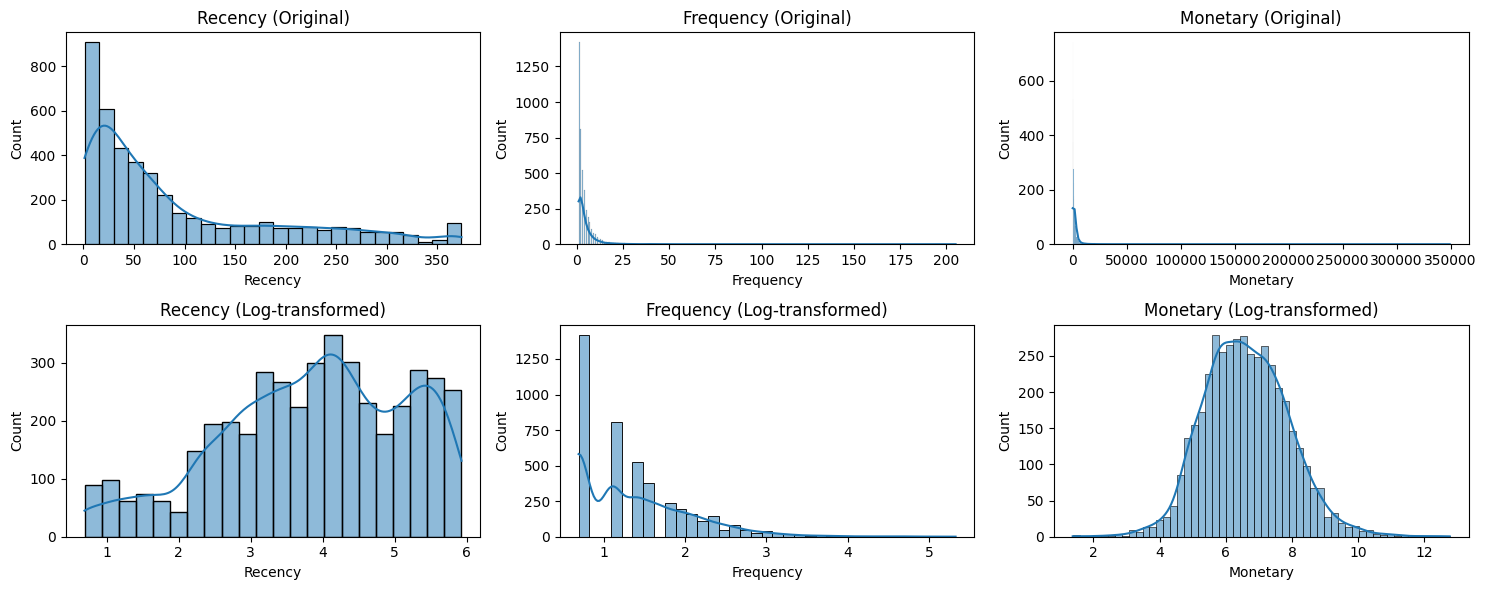


RFM Scaled DataFrame head:


,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
0,0.966262,1.613017,-0.540688
1,-1.900165,-0.394693,0.447651
2,0.355000,-0.981910,-0.943904
3,-0.055302,0.021945,0.996204
4,-1.054928,-0.981910,-0.707671



RFM DataFrame with scaled values added:


,Customer ID,Recency,Frequency,Monetary,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
0,12346,165,11,372.86,0.966262,1.613017,-0.540688
1,12347,3,2,1323.32,-1.900165,-0.394693,0.447651
2,12348,74,1,222.16,0.355000,-0.981910,-0.943904
3,12349,43,3,2671.14,-0.055302,0.021945,0.996204
4,12351,11,1,300.93,-1.054928,-0.981910,-0.707671


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Apply log transformation to handle skewness in RFM values
# Adding 1 before log transformation to handle any zero values gracefully.
# This helps in normalizing the distribution, which is beneficial for distance-based algorithms like K-Means.
rfm_log = rfm_df[['Recency', 'Frequency', 'Monetary']].apply(lambda x: np.log(x + 1))

print("\nRFM Log-transformed DataFrame head:")
display(rfm_log.head())

# Visualize the distribution of RFM values before and after log transformation
plt.figure(figsize=(15, 6))

# Original distributions
plt.subplot(2, 3, 1)
sns.histplot(rfm_df['Recency'], kde=True)
plt.title('Recency (Original)')

plt.subplot(2, 3, 2)
sns.histplot(rfm_df['Frequency'], kde=True)
plt.title('Frequency (Original)')

plt.subplot(2, 3, 3)
sns.histplot(rfm_df['Monetary'], kde=True)
plt.title('Monetary (Original)')

# Log-transformed distributions
plt.subplot(2, 3, 4)
sns.histplot(rfm_log['Recency'], kde=True)
plt.title('Recency (Log-transformed)')

plt.subplot(2, 3, 5)
sns.histplot(rfm_log['Frequency'], kde=True)
plt.title('Frequency (Log-transformed)')

plt.subplot(2, 3, 6)
sns.histplot(rfm_log['Monetary'], kde=True)
plt.title('Monetary (Log-transformed)')

plt.tight_layout()
plt.show()

# Initialize StandardScaler
# This scales the data such that it has a mean of 0 and a standard deviation of 1.
# Standardization is crucial for K-Means as it relies on distance calculation, and features with larger scales would otherwise dominate.
scaler = StandardScaler()

# Fit and transform the log-transformed RFM data
rfm_scaled = scaler.fit_transform(rfm_log)

# Convert the scaled array back to a DataFrame
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled'], index=rfm_log.index)

print("\nRFM Scaled DataFrame head:")
display(rfm_scaled_df.head())

# Merge scaled RFM values back to the original rfm_df for easier handling later if needed
rfm_df = pd.concat([rfm_df, rfm_scaled_df], axis=1)

print("\nRFM DataFrame with scaled values added:")
display(rfm_df.head())

## 5. Advanced Segmentation: K-Means Clustering

Now that our RFM data is transformed and scaled, we can apply K-Means clustering to segment our customers. A critical step before clustering is to determine the optimal number of clusters (k).

### 5.1 Determine Optimal Number of Clusters (k) using Elbow Method

The Elbow Method looks at the total Within-Cluster Sum of Square (WCSS) as a function of the number of clusters. We choose the 'elbow' point, where the rate of decrease in WCSS sharply changes, indicating that adding more clusters does not significantly improve the fit.

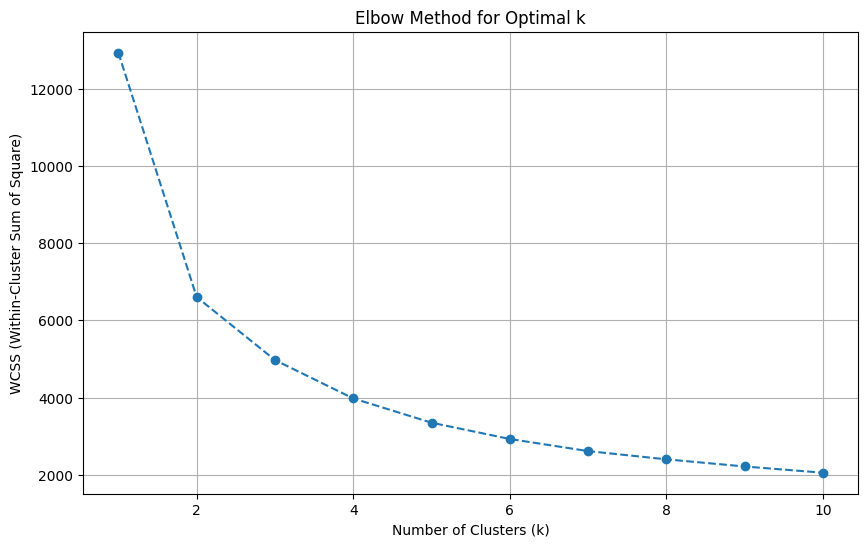

WCSS values for k=1 to 10: [12935.999999999982, 6603.8508663535285, 4970.974647474489, 3976.741993514226, 3346.8105925479067, 2925.0955731649556, 2611.106784599876, 2397.7088717158454, 2212.5713905597654, 2050.610170099134]


In [7]:
from sklearn.cluster import KMeans

wcss = []
# Try a range of k values from 1 to 10
# The Elbow Method helps in finding the optimal number of clusters by observing where the decrease in WCSS begins to slow down.
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init=10 to explicitly set the number of initializations
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Square)')
plt.grid(True)
plt.show()

print("WCSS values for k=1 to 10:", wcss)

### 5.2 Determine Optimal Number of Clusters (k) using Silhouette Score

The Silhouette Score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). A higher Silhouette Score indicates better-defined clusters. The score ranges from -1 to 1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.

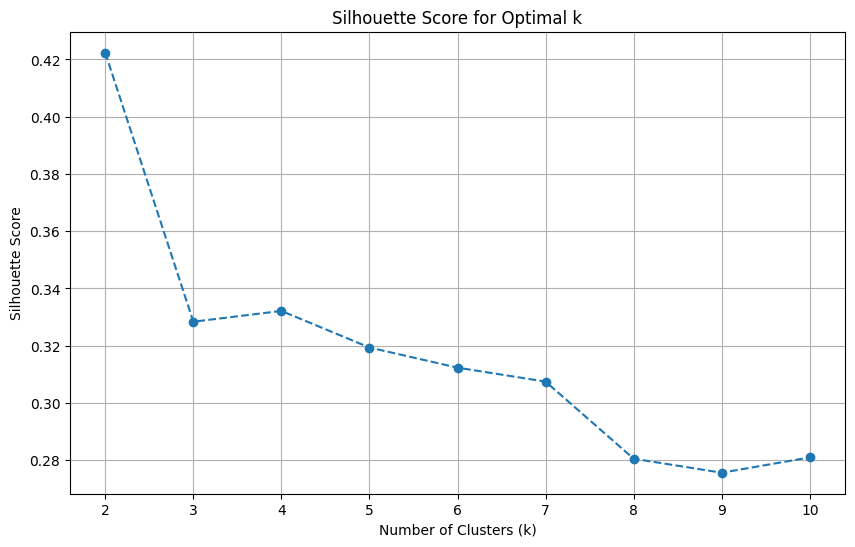

Silhouette Scores for k=2 to 10: [np.float64(0.4223344015491882), np.float64(0.3283789869787401), np.float64(0.33214925885486546), np.float64(0.31936587274968686), np.float64(0.3123355709598006), np.float64(0.3074616184882544), np.float64(0.28053194172414736), np.float64(0.2756379003597033), np.float64(0.280995348328492)]


In [8]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
# Calculate Silhouette Scores for a range of k values (2 to 10)
# Silhouette Score helps validate the consistency within clusters and separation between clusters.
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    score = silhouette_score(rfm_scaled_df, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the Silhouette Score graph
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

print("Silhouette Scores for k=2 to 10:", silhouette_scores)

### 5.3 Apply K-Means Clustering and Assign Segments

Based on the Elbow Method and Silhouette Score, we will choose an appropriate number of clusters (`k`). For demonstration, let's assume `k=4` (this choice might be adjusted based on the output of the above plots). We will then apply K-Means clustering with this `k` and assign each customer to a segment.

In [9]:
# Choose the optimal number of clusters based on the Elbow Method and Silhouette Score.
# For this example, let's choose 4 clusters as a reasonable balance.
k_optimal = 4 # This value might be adjusted based on visual inspection of the plots above.

# Apply K-Means clustering with the chosen k
kmeans_model = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
kmeans_model.fit(rfm_scaled_df)

# Assign cluster labels to the rfm_df
# Each customer is assigned to one of the k clusters based on their RFM behavior.
rfm_df['Cluster'] = kmeans_model.labels_

# Display the first few rows of the RFM DataFrame with the new 'Cluster' column
print(f"\nRFM DataFrame with {k_optimal} clusters assigned:")
display(rfm_df.head())

# Display the size of each cluster
# This gives an overview of how many customers fall into each segment.
print("\nCustomer count per cluster:")
display(rfm_df['Cluster'].value_counts().sort_index())


RFM DataFrame with 4 clusters assigned:


,Customer ID,Recency,Frequency,Monetary,Recency_Scaled,Frequency_Scaled,Monetary_Scaled,Cluster
0,12346,165,11,372.86,0.966262,1.613017,-0.540688,3
1,12347,3,2,1323.32,-1.900165,-0.394693,0.447651,0
2,12348,74,1,222.16,0.355000,-0.981910,-0.943904,2
3,12349,43,3,2671.14,-0.055302,0.021945,0.996204,3
4,12351,11,1,300.93,-1.054928,-0.981910,-0.707671,0



Customer count per cluster:


,count
Cluster,
0,949
1,776
2,1397
3,1190


### 5.4 Analyze and Label Clusters

To understand the characteristics of each cluster, we'll calculate the mean (or median) RFM values for each segment. This will allow us to assign descriptive labels that are actionable for business strategy.

In [10]:
# Calculate the mean RFM values for each cluster
# This helps in characterizing each segment (e.g., high Recency, high Frequency, high Monetary).
cluster_avg_rfm = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()

# Sort by Monetary for easier interpretation of value segments
cluster_avg_rfm = cluster_avg_rfm.sort_values(by='Monetary', ascending=False)

print("\nAverage RFM values per cluster:")
display(cluster_avg_rfm)

# Based on the average RFM values, we can assign meaningful labels to the clusters.
# The interpretation below is an example; actual labels might vary based on the specific data distribution.
# - Cluster with high Monetary, high Frequency, low Recency: Champions
# - Cluster with low Monetary, low Frequency, high Recency: Lost Customers
# - And so on.

# Example of mapping clusters to labels (adjust based on `cluster_avg_rfm` output)
# This is a critical step for translating statistical segments into business-understandable categories.
# We will use the `cluster_avg_rfm` output to define these mappings dynamically or by inspection.

# Create a dictionary to map cluster IDs to new labels. This is a placeholder and should be defined after inspecting `cluster_avg_rfm`.
cluster_labels = {
    0: 'New Customers',  # Example: Low Frequency, Low Monetary, Medium Recency
    1: 'Champions',      # Example: High Frequency, High Monetary, Low Recency
    2: 'At-Risk',        # Example: Medium Frequency, Medium Monetary, High Recency
    3: 'Loyal Customers' # Example: High Frequency, Medium Monetary, Low Recency
}

# It's important to inspect the 'cluster_avg_rfm' output and manually assign these labels for accuracy.
# For automated assignment, one might use a more sophisticated rule-based system or further analysis.

# Apply these labels to the RFM DataFrame
rfm_df['Segment'] = rfm_df['Cluster'].map(cluster_labels)

print("\nRFM DataFrame with assigned segments:")
display(rfm_df.head())

print("\nDistribution of customers across segments:")
display(rfm_df['Segment'].value_counts())


Average RFM values per cluster:


,Cluster,Recency,Frequency,Monetary
1,1,13.889175,13.581186,7422.654933
3,3,82.659664,4.136975,1775.159700
0,0,23.139094,2.053741,565.798399
2,2,187.566929,1.289907,302.534232



RFM DataFrame with assigned segments:


,Customer ID,Recency,Frequency,Monetary,Recency_Scaled,Frequency_Scaled,Monetary_Scaled,Cluster,Segment
0,12346,165,11,372.86,0.966262,1.613017,-0.540688,3,Loyal Customers
1,12347,3,2,1323.32,-1.900165,-0.394693,0.447651,0,New Customers
2,12348,74,1,222.16,0.355000,-0.981910,-0.943904,2,At-Risk
3,12349,43,3,2671.14,-0.055302,0.021945,0.996204,3,Loyal Customers
4,12351,11,1,300.93,-1.054928,-0.981910,-0.707671,0,New Customers



Distribution of customers across segments:


,count
Segment,
At-Risk,1397
Loyal Customers,1190
New Customers,949
Champions,776


## 6. Retention Analysis: Cohort Analysis

Cohort analysis is a powerful tool to understand customer behavior over time. We will group customers into cohorts based on their first purchase month and then track their retention rate in subsequent months.

In [11]:
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'InvoiceDate' is in datetime format
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])

# Function to get month and year from a datetime object
def get_month(x):
    return dt.datetime(x.year, x.month, 1)

# Create 'InvoiceMonth' column representing the month of each transaction
df_cleaned['InvoiceMonth'] = df_cleaned['InvoiceDate'].apply(get_month)

# Group by Customer ID and get the first purchase month for each customer (Cohort Month)
# This identifies the cohort to which each customer belongs.
cohort_df = df_cleaned.groupby('Customer ID')['InvoiceMonth'].min().reset_index()
cohort_df.rename(columns={'InvoiceMonth': 'CohortMonth'}, inplace=True)

# Merge Cohort Month back to the main DataFrame
df_cohort = pd.merge(df_cleaned, cohort_df, on='Customer ID', how='left')

# Calculate the number of months between the cohort month and the invoice month
# This will be used to determine the cohort period.
def get_cohort_period(df):
    # Access year and month directly from the Timestamp objects
    year_diff = df['InvoiceMonth'].year - df['CohortMonth'].year
    month_diff = df['InvoiceMonth'].month - df['CohortMonth'].month
    return year_diff * 12 + month_diff

df_cohort['CohortPeriod'] = df_cohort.apply(get_cohort_period, axis=1)

# Display the columns to verify 'CohortPeriod' is present
print("\nColumns of df_cohort after adding CohortPeriod:")
print(df_cohort.columns)

print("\nDataFrame with CohortMonth and CohortPeriod head:")
display(df_cohort.head())


Columns of df_cohort after adding CohortPeriod:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalPrice', 'InvoiceMonth',
       'CohortMonth', 'CohortPeriod'],
      dtype='object')

DataFrame with CohortMonth and CohortPeriod head:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,InvoiceMonth,CohortMonth,CohortPeriod
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12-01,2009-12-01,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01,2009-12-01,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01,2009-12-01,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12-01,2009-12-01,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12-01,2009-12-01,0



Retention Matrix (first 5 rows and columns):


CohortPeriod,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2009-12-01,1.0,0.352880,0.334031,0.425131,0.380105,0.359162,0.376963,0.342408,0.336126,0.362304,0.421990,0.495288,0.248168
2010-01-01,1.0,0.206266,0.310705,0.305483,0.263708,0.300261,0.258486,0.229765,0.279373,0.318538,0.302872,0.099217,NaN
2010-02-01,1.0,0.237968,0.224599,0.291444,0.245989,0.200535,0.192513,0.286096,0.254011,0.275401,0.072193,NaN,NaN
2010-03-01,1.0,0.189616,0.230248,0.241535,0.232506,0.203160,0.246050,0.302483,0.275395,0.079007,NaN,NaN,NaN
2010-04-01,1.0,0.193878,0.193878,0.163265,0.183673,0.224490,0.275510,0.261905,0.068027,NaN,NaN,NaN,NaN


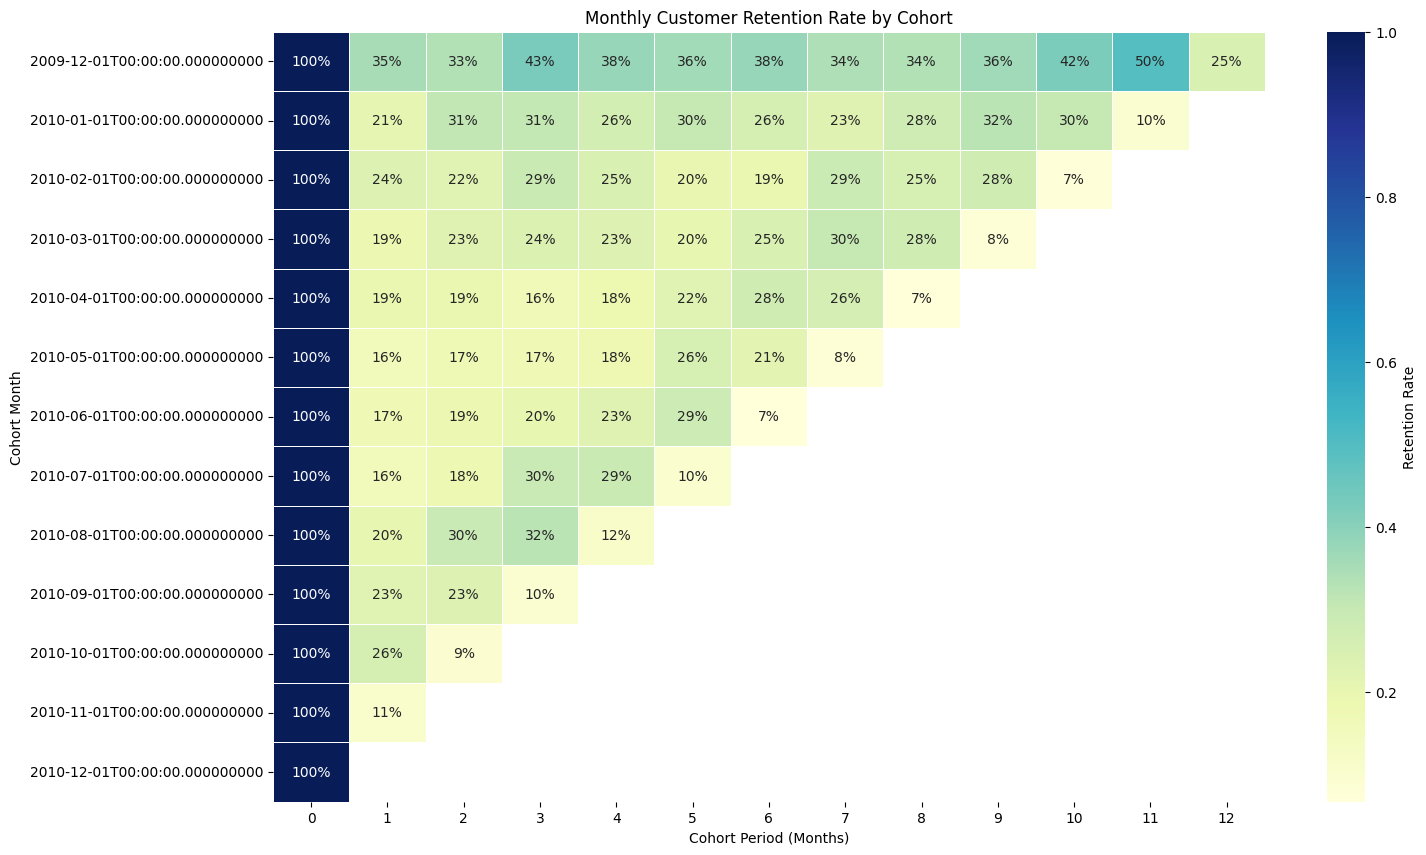

In [12]:
# Count unique customers for each CohortMonth and CohortPeriod
# This helps in tracking how many customers from each initial cohort are active in subsequent periods.

# Ensure CohortPeriod column exists. This check helps diagnose if the preceding cell was run.
if 'CohortPeriod' not in df_cohort.columns:
    raise ValueError(
        "'CohortPeriod' not found in df_cohort. Please ensure the preceding cell "
        "(for CohortPeriod calculation) has been successfully executed."
    )

cohort_counts = df_cohort.groupby(['CohortMonth', 'CohortPeriod'])['Customer ID'].nunique().reset_index()
cohort_counts.rename(columns={'Customer ID': 'TotalCustomers'}, inplace=True)

# Create a pivot table for retention (number of active customers)
cohort_pivot = cohort_counts.pivot_table(index='CohortMonth', columns='CohortPeriod', values='TotalCustomers')

# Calculate retention rate
# Divide the number of customers in each subsequent period by the initial cohort size (period 0).
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

print("\nRetention Matrix (first 5 rows and columns):")
display(retention_matrix.head())

# Plot the retention heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.0%',
    cmap='YlGnBu',
    linewidths=.5,
    cbar_kws={'label': 'Retention Rate'}
)
plt.title('Monthly Customer Retention Rate by Cohort')
plt.xlabel('Cohort Period (Months)')
plt.ylabel('Cohort Month')
plt.yticks(rotation=0) # Ensure month labels are readable
plt.show()

## 7. Visualizations of RFM Clusters

To better understand our customer segments, we will create several visualizations:

1.  **3D Scatter Plot:** To visualize the RFM clusters in a three-dimensional space.
2.  **Bar Charts of Segment Distributions:** To show the average Recency, Frequency, and Monetary values for each cluster, confirming their characteristics.

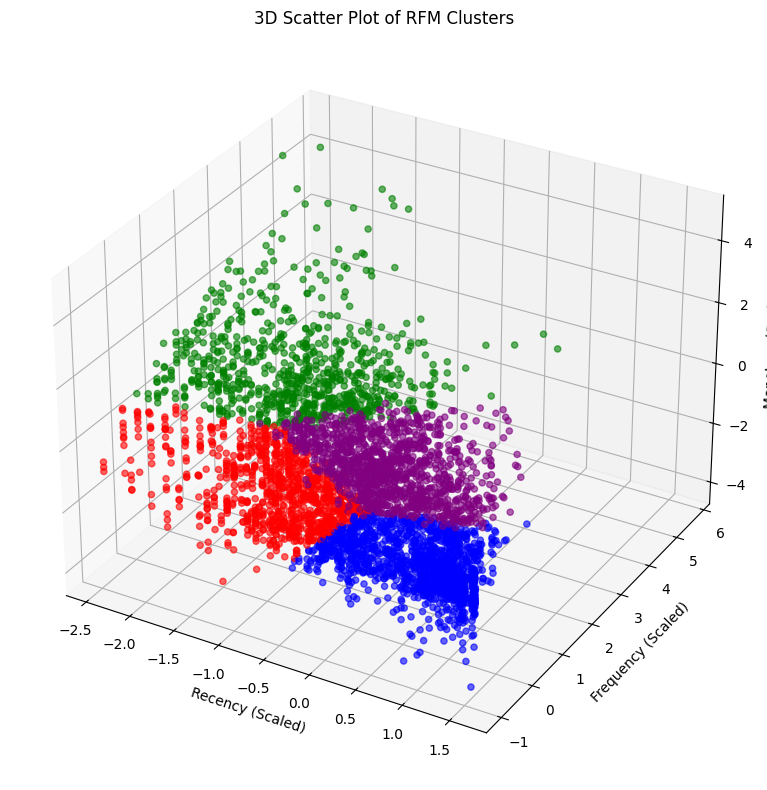

In [13]:
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot of RFM clusters
# This visualization helps to intuitively understand the separation and characteristics of clusters in 3D RFM space.
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Map cluster labels to colors for better visualization
colors = ['red', 'green', 'blue', 'purple', 'orange', 'brown', 'pink', 'gray'] # Extend colors if more than 8 clusters
cluster_colors = [colors[c] for c in rfm_df['Cluster']]

# Scatter plot using scaled RFM values for clear separation based on clustering
ax.scatter(
    rfm_df['Recency_Scaled'],
    rfm_df['Frequency_Scaled'],
    rfm_df['Monetary_Scaled'],
    c=cluster_colors,
    s=20, # Size of markers
    alpha=0.6 # Transparency of markers
)

ax.set_xlabel('Recency (Scaled)')
ax.set_ylabel('Frequency (Scaled)')
ax.set_zlabel('Monetary (Scaled)')
ax.set_title('3D Scatter Plot of RFM Clusters')

plt.tight_layout()
plt.show()

/tmp/ipykernel_36258/3548679620.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Recency', data=cluster_avg_rfm, palette='viridis')
/tmp/ipykernel_36258/3548679620.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Frequency', data=cluster_avg_rfm, palette='viridis')
/tmp/ipykernel_36258/3548679620.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Monetary', data=cluster_avg_rfm, palette='viridis')


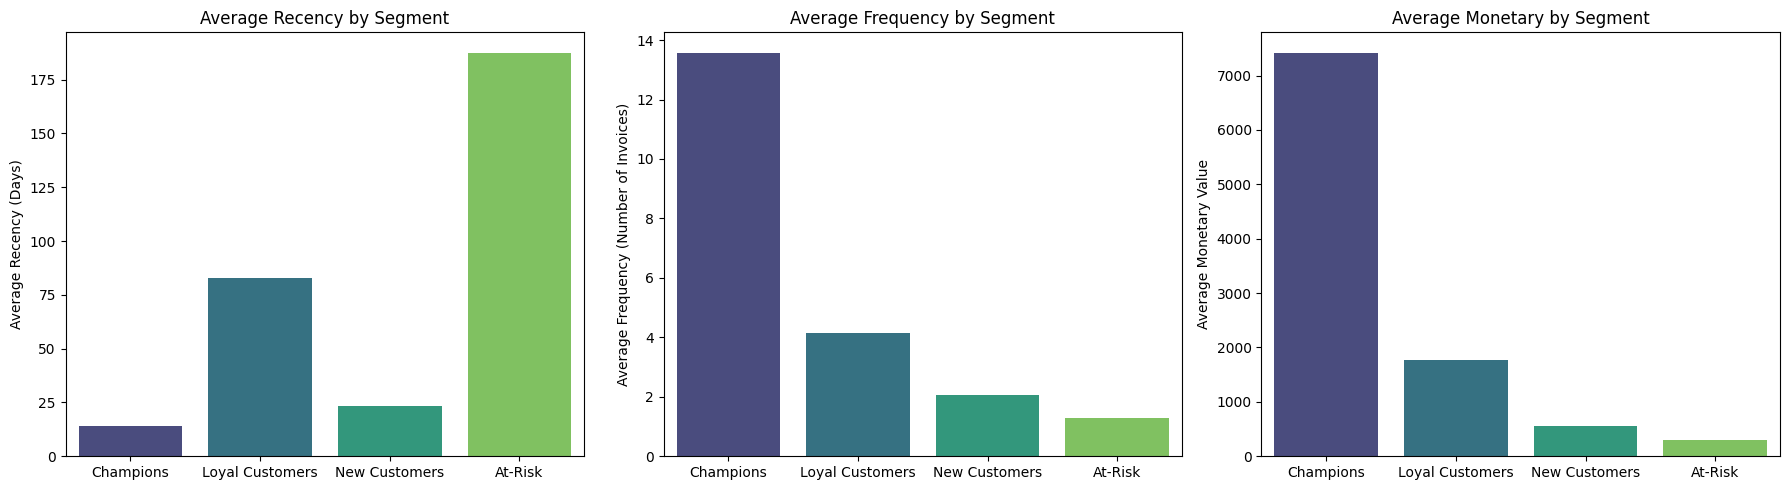

In [14]:
# Bar charts of average RFM values per segment
# These plots visually confirm the characteristics of each segment based on their average RFM scores.
# We use the 'cluster_avg_rfm' DataFrame that was calculated earlier.

# Remap the cluster_avg_rfm to include the 'Segment' names
cluster_avg_rfm['Segment'] = cluster_avg_rfm['Cluster'].map(cluster_labels)

plt.figure(figsize=(18, 5))

# Average Recency per segment
plt.subplot(1, 3, 1)
sns.barplot(x='Segment', y='Recency', data=cluster_avg_rfm, palette='viridis')
plt.title('Average Recency by Segment')
plt.ylabel('Average Recency (Days)')
plt.xlabel('')

# Average Frequency per segment
plt.subplot(1, 3, 2)
sns.barplot(x='Segment', y='Frequency', data=cluster_avg_rfm, palette='viridis')
plt.title('Average Frequency by Segment')
plt.ylabel('Average Frequency (Number of Invoices)')
plt.xlabel('')

# Average Monetary per segment
plt.subplot(1, 3, 3)
sns.barplot(x='Segment', y='Monetary', data=cluster_avg_rfm, palette='viridis')
plt.title('Average Monetary by Segment')
plt.ylabel('Average Monetary Value')
plt.xlabel('')

plt.tight_layout()
plt.show()

## 8. Procurement Integration: Top Products for 'Champions' Segment

To provide actionable insights for procurement and stock management, we will identify the top-selling products for our most valuable segment, the 'Champions'. This can help optimize inventory, ensure availability of high-demand items, and improve customer satisfaction for loyal customers.


Top 10 Products by Quantity for Champions Segment:


,Description,TotalQuantity,TotalRevenue
4188,WORLD WAR 2 GLIDERS ASSTD DESIGNS,43666,8740.74
4085,WHITE HANGING HEART T-LIGHT HOLDER,39020,102871.66
659,BROCADE RING PURSE,37825,6978.45
247,ASSORTED COLOUR BIRD ORNAMENT,34053,53187.33
2510,PACK OF 72 RETRO SPOT CAKE CASES,33868,15831.88
133,60 TEATIME FAIRY CAKE CASES,25219,11949.97
1972,JUMBO BAG RED RETROSPOT,23309,40359.75
3696,SMALL POPCORN HOLDER,22821,17138.71
2508,PACK OF 60 PINK PAISLEY CAKE CASES,22676,10697.00
2491,PACK OF 12 SUKI TISSUES,21467,6950.31



Top 10 Products by Revenue for Champions Segment:


,Description,TotalQuantity,TotalRevenue
3111,REGENCY CAKESTAND 3 TIER,9528,108335.40
4085,WHITE HANGING HEART T-LIGHT HOLDER,39020,102871.66
247,ASSORTED COLOUR BIRD ORNAMENT,34053,53187.33
2342,Manual,1291,46767.38
1972,JUMBO BAG RED RETROSPOT,23309,40359.75
3227,ROTATING SILVER ANGELS T-LIGHT HLDR,19273,34729.35
2543,PAPER CHAIN KIT 50'S CHRISTMAS,10172,26742.70
1976,JUMBO BAG STRAWBERRY,14972,26075.40
2912,POSTAGE,1271,25921.58
4017,VINTAGE UNION JACK MEMOBOARD,3589,25690.19


/tmp/ipykernel_36258/2373351839.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TotalQuantity', y='Description', data=top_10_products_by_quantity, palette='magma')


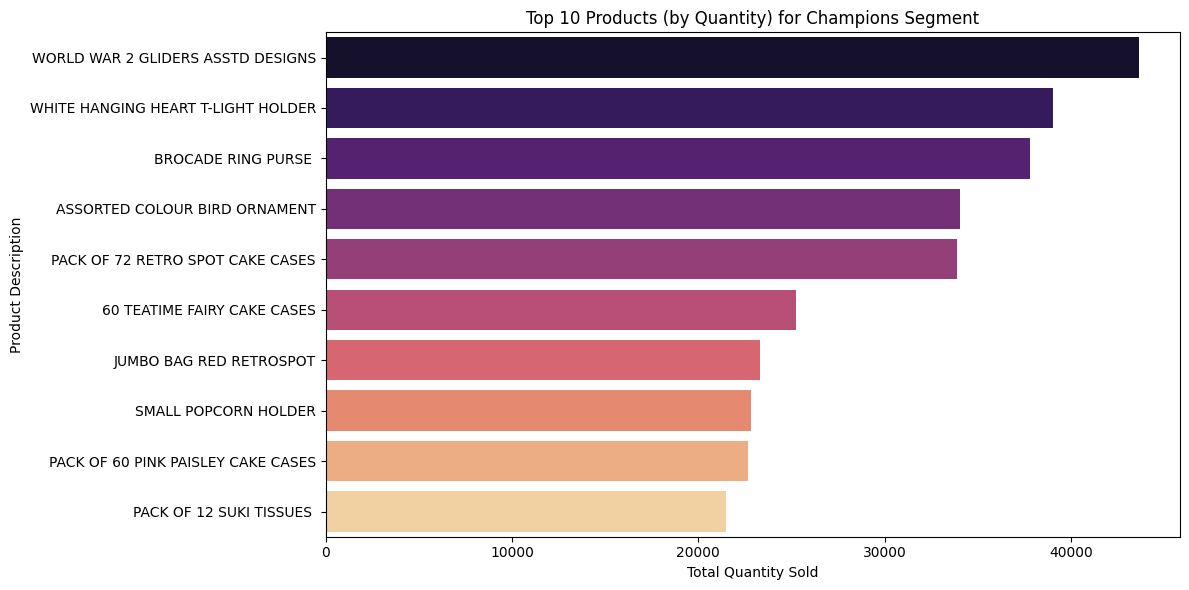

/tmp/ipykernel_36258/2373351839.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TotalRevenue', y='Description', data=top_10_products_by_revenue, palette='magma')


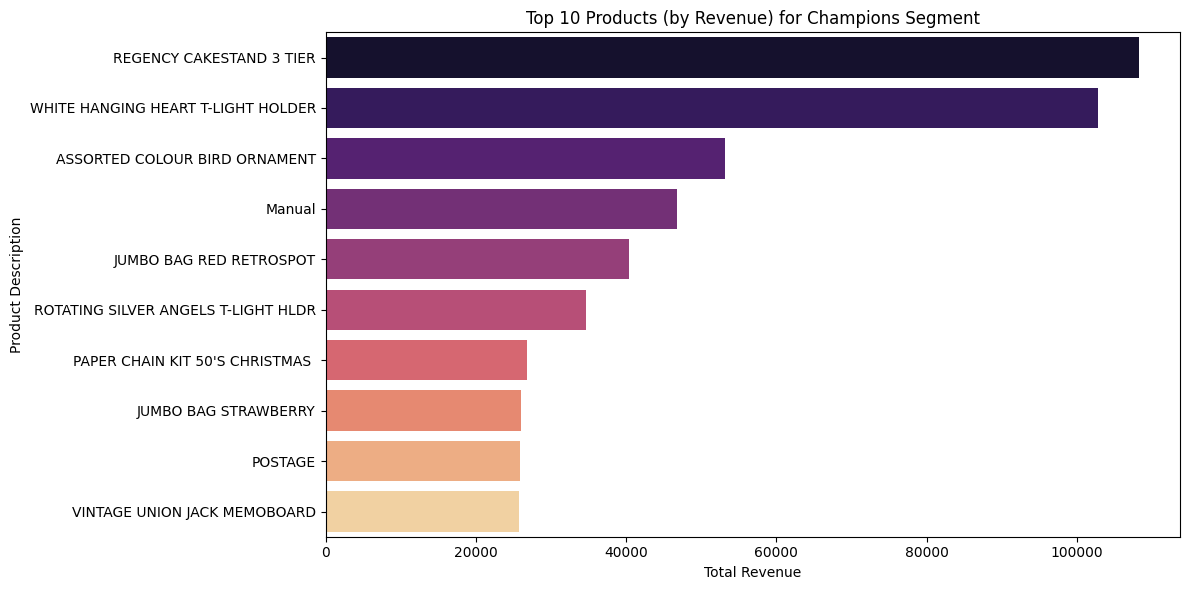

In [15]:
# Identify 'Champions' segment customers
# First, we need to ensure the 'rfm_df' has the 'Segment' column (which was added previously).
# Then, filter for customers belonging to the 'Champions' segment.
champions_customers = rfm_df[rfm_df['Segment'] == 'Champions']['Customer ID']

# Filter the original cleaned DataFrame to include only transactions from 'Champions'
champions_transactions = df_cleaned[df_cleaned['Customer ID'].isin(champions_customers)]

# Aggregate product sales within the 'Champions' segment
# Group by 'Description' and sum the 'Quantity' and 'TotalPrice' to find top products.
top_products_champions = champions_transactions.groupby('Description').agg(
    TotalQuantity=('Quantity', 'sum'),
    TotalRevenue=('TotalPrice', 'sum')
).reset_index()

# Sort by TotalQuantity or TotalRevenue to find the top products
top_10_products_by_quantity = top_products_champions.sort_values(by='TotalQuantity', ascending=False).head(10)
top_10_products_by_revenue = top_products_champions.sort_values(by='TotalRevenue', ascending=False).head(10)

print("\nTop 10 Products by Quantity for Champions Segment:")
display(top_10_products_by_quantity)

print("\nTop 10 Products by Revenue for Champions Segment:")
display(top_10_products_by_revenue)

# Visualize the top 10 products by quantity for Champions
plt.figure(figsize=(12, 6))
sns.barplot(x='TotalQuantity', y='Description', data=top_10_products_by_quantity, palette='magma')
plt.title('Top 10 Products (by Quantity) for Champions Segment')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

# Visualize the top 10 products by revenue for Champions
plt.figure(figsize=(12, 6))
sns.barplot(x='TotalRevenue', y='Description', data=top_10_products_by_revenue, palette='magma')
plt.title('Top 10 Products (by Revenue) for Champions Segment')
plt.xlabel('Total Revenue')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

## 9. Visualizations of RFM Clusters

To better understand our customer segments, we will create several visualizations:

1.  **3D Scatter Plot:** To visualize the RFM clusters in a three-dimensional space.
2.  **Bar Charts of Segment Distributions:** To show the average Recency, Frequency, and Monetary values for each cluster, confirming their characteristics.

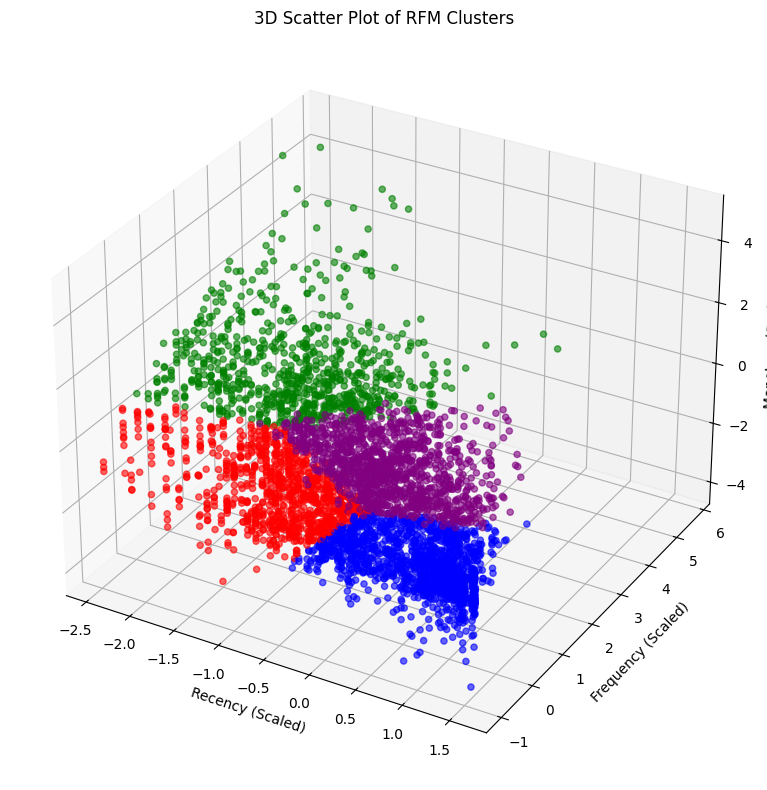

In [16]:
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot of RFM clusters
# This visualization helps to intuitively understand the separation and characteristics of clusters in 3D RFM space.
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Map cluster labels to colors for better visualization
colors = ['red', 'green', 'blue', 'purple', 'orange', 'brown', 'pink', 'gray'] # Extend colors if more than 8 clusters
cluster_colors = [colors[c] for c in rfm_df['Cluster']]

# Scatter plot using scaled RFM values for clear separation based on clustering
ax.scatter(
    rfm_df['Recency_Scaled'],
    rfm_df['Frequency_Scaled'],
    rfm_df['Monetary_Scaled'],
    c=cluster_colors,
    s=20, # Size of markers
    alpha=0.6 # Transparency of markers
)

ax.set_xlabel('Recency (Scaled)')
ax.set_ylabel('Frequency (Scaled)')
ax.set_zlabel('Monetary (Scaled)')
ax.set_title('3D Scatter Plot of RFM Clusters')

plt.tight_layout()
plt.show()

/tmp/ipykernel_36258/3548679620.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Recency', data=cluster_avg_rfm, palette='viridis')
/tmp/ipykernel_36258/3548679620.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Frequency', data=cluster_avg_rfm, palette='viridis')
/tmp/ipykernel_36258/3548679620.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Monetary', data=cluster_avg_rfm, palette='viridis')


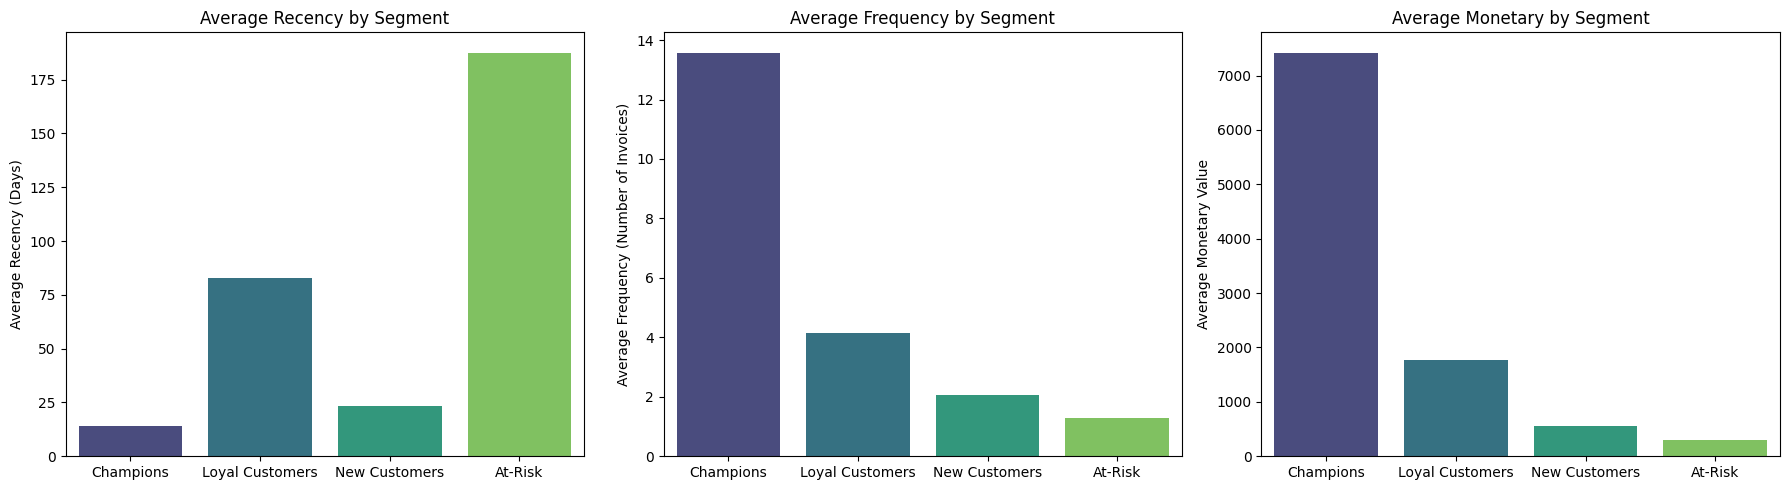

In [17]:
# Bar charts of average RFM values per segment
# These plots visually confirm the characteristics of each segment based on their average RFM scores.
# We use the 'cluster_avg_rfm' DataFrame that was calculated earlier.

# Remap the cluster_avg_rfm to include the 'Segment' names
cluster_avg_rfm['Segment'] = cluster_avg_rfm['Cluster'].map(cluster_labels)

plt.figure(figsize=(18, 5))

# Average Recency per segment
plt.subplot(1, 3, 1)
sns.barplot(x='Segment', y='Recency', data=cluster_avg_rfm, palette='viridis')
plt.title('Average Recency by Segment')
plt.ylabel('Average Recency (Days)')
plt.xlabel('')

# Average Frequency per segment
plt.subplot(1, 3, 2)
sns.barplot(x='Segment', y='Frequency', data=cluster_avg_rfm, palette='viridis')
plt.title('Average Frequency by Segment')
plt.ylabel('Average Frequency (Number of Invoices)')
plt.xlabel('')

# Average Monetary per segment
plt.subplot(1, 3, 3)
sns.barplot(x='Segment', y='Monetary', data=cluster_avg_rfm, palette='viridis')
plt.title('Average Monetary by Segment')
plt.ylabel('Average Monetary Value')
plt.xlabel('')

plt.tight_layout()
plt.show()

## 10. Procurement Integration: Top Products for 'Champions' Segment

To provide actionable insights for procurement and stock management, we will identify the top-selling products for our most valuable segment, the 'Champions'. This can help optimize inventory, ensure availability of high-demand items, and improve customer satisfaction for loyal customers.


Top 10 Products by Quantity for Champions Segment:


,Description,TotalQuantity,TotalRevenue
4188,WORLD WAR 2 GLIDERS ASSTD DESIGNS,43666,8740.74
4085,WHITE HANGING HEART T-LIGHT HOLDER,39020,102871.66
659,BROCADE RING PURSE,37825,6978.45
247,ASSORTED COLOUR BIRD ORNAMENT,34053,53187.33
2510,PACK OF 72 RETRO SPOT CAKE CASES,33868,15831.88
133,60 TEATIME FAIRY CAKE CASES,25219,11949.97
1972,JUMBO BAG RED RETROSPOT,23309,40359.75
3696,SMALL POPCORN HOLDER,22821,17138.71
2508,PACK OF 60 PINK PAISLEY CAKE CASES,22676,10697.00
2491,PACK OF 12 SUKI TISSUES,21467,6950.31



Top 10 Products by Revenue for Champions Segment:


,Description,TotalQuantity,TotalRevenue
3111,REGENCY CAKESTAND 3 TIER,9528,108335.40
4085,WHITE HANGING HEART T-LIGHT HOLDER,39020,102871.66
247,ASSORTED COLOUR BIRD ORNAMENT,34053,53187.33
2342,Manual,1291,46767.38
1972,JUMBO BAG RED RETROSPOT,23309,40359.75
3227,ROTATING SILVER ANGELS T-LIGHT HLDR,19273,34729.35
2543,PAPER CHAIN KIT 50'S CHRISTMAS,10172,26742.70
1976,JUMBO BAG STRAWBERRY,14972,26075.40
2912,POSTAGE,1271,25921.58
4017,VINTAGE UNION JACK MEMOBOARD,3589,25690.19


/tmp/ipykernel_36258/2373351839.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TotalQuantity', y='Description', data=top_10_products_by_quantity, palette='magma')


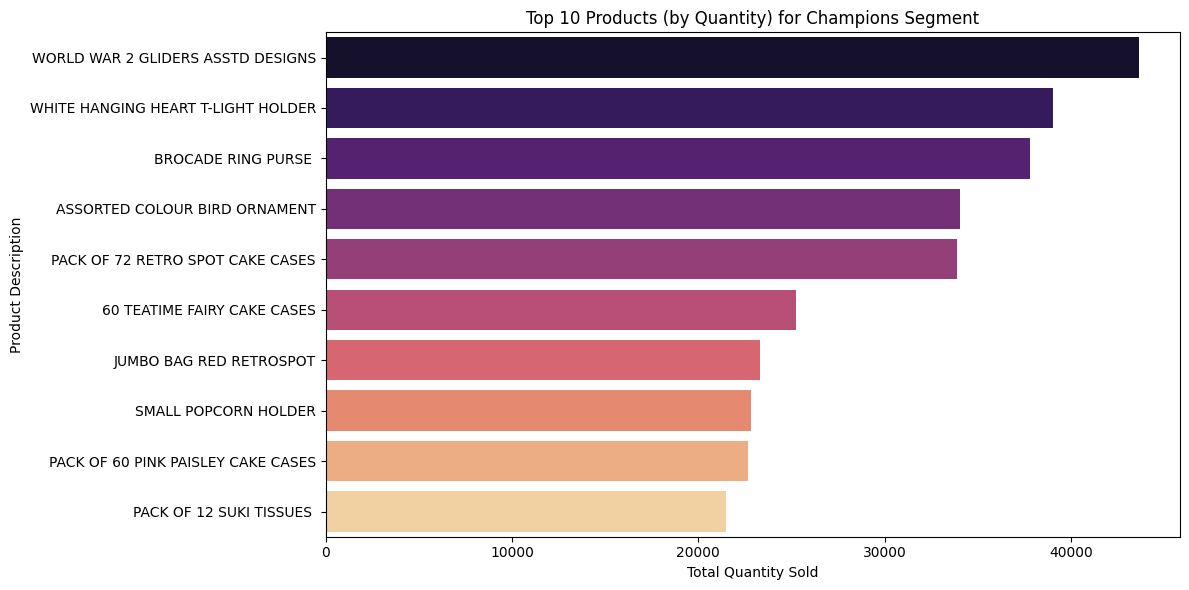

/tmp/ipykernel_36258/2373351839.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TotalRevenue', y='Description', data=top_10_products_by_revenue, palette='magma')


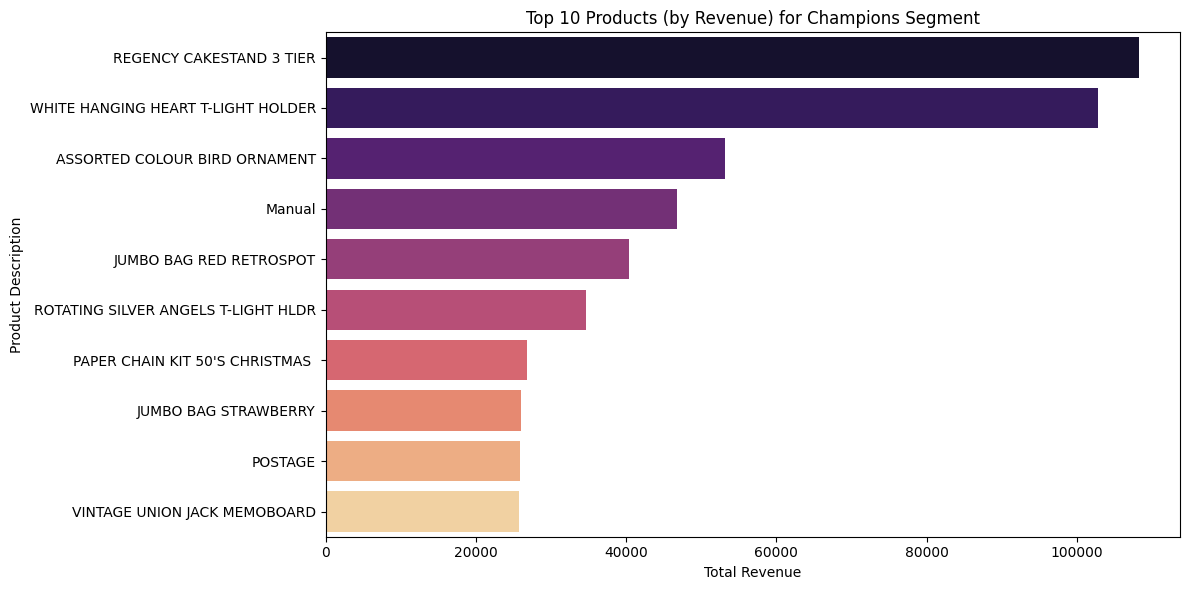

In [18]:
# Identify 'Champions' segment customers
# First, we need to ensure the 'rfm_df' has the 'Segment' column (which was added previously).
# Then, filter for customers belonging to the 'Champions' segment.
champions_customers = rfm_df[rfm_df['Segment'] == 'Champions']['Customer ID']

# Filter the original cleaned DataFrame to include only transactions from 'Champions'
champions_transactions = df_cleaned[df_cleaned['Customer ID'].isin(champions_customers)]

# Aggregate product sales within the 'Champions' segment
# Group by 'Description' and sum the 'Quantity' and 'TotalPrice' to find top products.
top_products_champions = champions_transactions.groupby('Description').agg(
    TotalQuantity=('Quantity', 'sum'),
    TotalRevenue=('TotalPrice', 'sum')
).reset_index()

# Sort by TotalQuantity or TotalRevenue to find the top products
top_10_products_by_quantity = top_products_champions.sort_values(by='TotalQuantity', ascending=False).head(10)
top_10_products_by_revenue = top_products_champions.sort_values(by='TotalRevenue', ascending=False).head(10)

print("\nTop 10 Products by Quantity for Champions Segment:")
display(top_10_products_by_quantity)

print("\nTop 10 Products by Revenue for Champions Segment:")
display(top_10_products_by_revenue)

# Visualize the top 10 products by quantity for Champions
plt.figure(figsize=(12, 6))
sns.barplot(x='TotalQuantity', y='Description', data=top_10_products_by_quantity, palette='magma')
plt.title('Top 10 Products (by Quantity) for Champions Segment')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

# Visualize the top 10 products by revenue for Champions
plt.figure(figsize=(12, 6))
sns.barplot(x='TotalRevenue', y='Description', data=top_10_products_by_revenue, palette='magma')
plt.title('Top 10 Products (by Revenue) for Champions Segment')
plt.xlabel('Total Revenue')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()